---
## ⤵️ Imports

In [ ]:
!pip install gensim nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 63.0 MB/s eta 0:00:00


In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.datasets import fetch_20newsgroups
from sklearn.metrics import silhouette_score
from sklearn.decomposition import NMF, PCA
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary
from gensim.models import LdaModel
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

import subprocess
import sys


---
## 1 | Load and Split the Dataset

In [ ]:
categories = [
  'comp.os.ms-windows.misc',
  'comp.sys.ibm.pc.hardware'
]

In [ ]:
df = fetch_20newsgroups(subset='train', categories=categories, remove=('headers', 'footers', 'quotes'))
data = df.data
target = df.target

X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state=42)

## 2 | Build Pipeline and Perform GridSearchCV for NMF Topic Modeling

In [ ]:
pipeline = Pipeline(steps=[
  ('tfidf', TfidfVectorizer(stop_words='english')),
  ('nmf', NMF(init='nndsvda', max_iter=200, random_state=42))
])

param_grid = {
  'tfidf__max_features': [1000, 5000, 10000],
  'nmf__n_components': [2, 5, 10]

}

In [ ]:
def nmf_silhouette_score(model, X, y=None):
  # Aplica o TFIDF ao corpus
  X_transformed = model.named_steps['tfidf'].transform(X)

  nmf_model = model.named_steps['nmf']
  t = nmf_model.transform(X_transformed)
  topics = np.argmax(t, axis=1)

  if len(np.unique(topics)) < 2:
    return -1

  return silhouette_score(t, topics, metric='euclidean')

In [ ]:
grid_search = GridSearchCV(
  pipeline,
  param_grid,
  cv=3,
  scoring=nmf_silhouette_score,
  verbose=2,
  refit=True,
  return_train_score=True,
  n_jobs=-1
)

In [ ]:
print('-==-'*10, '\nStarting the GridSearchCV...')

grid_search.fit(X_train, y_train)

print('-==-'*10, '\n GridSearchCV complete!')

-==--==--==--==--==--==--==--==--==--==- 
Starting the GridSearchCV...
Fitting 3 folds for each of 9 candidates, totalling 27 fits
-==--==--==--==--==--==--==--==--==--==- 
 GridSearchCV complete!


In [ ]:
print(f'Best params found: {grid_search.best_params_}')
print(f'Best cross-validation silhouette score: {grid_search.best_score_}')

best_pipeline = grid_search.best_estimator_
print(f'Best Pipeline: \n{best_pipeline}')

Best params found: {'nmf__n_components': 2, 'tfidf__max_features': 10000}
Best cross-validation silhouette score: 0.568566912204485
Best Pipeline: 
Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=10000, stop_words='english')),
                ('nmf', NMF(init='nndsvda', n_components=2, random_state=42))])


## 3| Analyze Best Model and Calculate Coherence Score

In [ ]:
best_tfidf = best_pipeline.named_steps['tfidf']
best_nmf = best_pipeline.named_steps['nmf']

feature_names = best_tfidf.get_feature_names_out()

In [ ]:
no_top_words = 10
nltk.download('punkt_tab') # Download the missing 'punkt_tab' resource
tokenized_data = [word_tokenize(doc.lower()) for doc in X_train]
dictionary= Dictionary(tokenized_data)
corpus = [dictionary.doc2bow(doc) for doc in tokenized_data]

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
def get_gensim_topics(nmf_model, feature_names, dictionary):
  gensim_topics = []

  for topic_idx, topic in enumerate(nmf_model.components_):
    top_feature_indices = topic.argsort()[:-no_top_words - 1:-1]
    top_words = [feature_names[i] for i in top_feature_indices]
    gensim_topics.append(top_words)

  return gensim_topics

In [ ]:
gensim_topics = get_gensim_topics(best_nmf, feature_names, dictionary)

calculate_model_nmf = CoherenceModel(
  topics=gensim_topics,
  texts=tokenized_data,
  dictionary=dictionary,
  coherence='u_mass'
)

coherence_score_nmf = calculate_model_nmf.get_coherence()


print(f'Coherence score for best NMF Model: {coherence_score_nmf:.4f}')

Coherence score for best NMF Model: -1.4609


In [ ]:
X_transformed = best_pipeline.named_steps['tfidf'].transform(X_train)
nmf_model = best_pipeline.named_steps['nmf']
t = nmf_model.transform(X_transformed)
topics = np.argmax(t, axis=1)

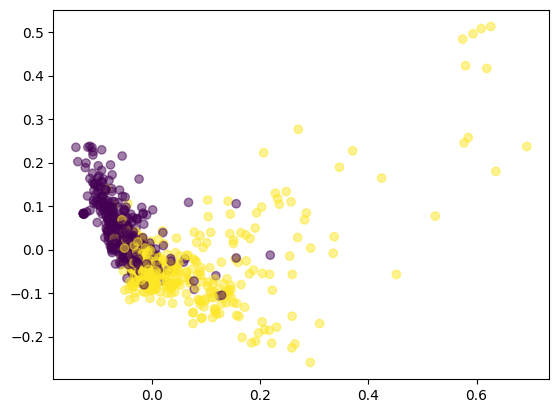

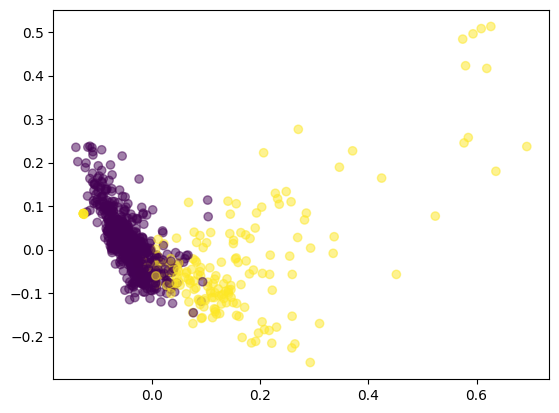

In [ ]:
pca_model = PCA(n_components=10)
X_train_pca = pca_model.fit_transform(best_pipeline.named_steps['tfidf'].transform(X_train))

i1, i2 = 0, 3

plt.figure()
plt.scatter(X_train_pca[:, i1], X_train_pca[:, i2], c=y_train, cmap='viridis', alpha=0.5)

plt.figure()
plt.scatter(X_train_pca[:, i1], X_train_pca[:, i2], c=topics, cmap='viridis', alpha=0.5)

## 4 | Evaluate the Best Model on Test Data

In [ ]:
X_test_transformed = best_pipeline.named_steps['tfidf'].transform(X_test)
X_test_topics = best_pipeline.named_steps['nmf'].transform(X_test_transformed)

labels_test = np.argmax(X_test_topics, axis=1)
if len(np.unique(labels_test)) >= 2:
  silhouette_test_score = silhouette_score(X_test_topics, labels_test, metric='euclidean')

tokenized_data_test = [word_tokenize(doc.lower()) for doc in X_test]


coherence_model_nmf_test = CoherenceModel(
    topics=gensim_topics,
    texts=tokenized_data_test,
    dictionary=dictionary,
    coherence='u_mass'
)

coherence_nmf_test = coherence_model_nmf_test.get_coherence()
print(f"Coherence Score for Test Data: {coherence_nmf_test:.4f}")

Coherence Score for Test Data: -1.7770


## 5 | LDA